# Computing dmax with the FleXgeo2 library API

`dmax` is a per-residue flexibility metric that measures the outlier-trimmed maximum spread in `(curvature, torsion)` space. This notebook shows how to compute it from Python without using the CLI, inspect the resulting columns, and tune the outlier threshold.

In [1]:
from pathlib import Path
import sys
import tempfile


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").is_file() and (candidate / "pdb2lj5.pdb").is_file():
            return candidate
    raise FileNotFoundError("Could not find the FleXgeo2 repo root containing pyproject.toml and pdb2lj5.pdb")


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

try:
    import matplotlib.pyplot as plt
    import melodia_py  # noqa: F401
    import pandas as pd
    from flexgeo2 import AnalysisConfig, FlexGeo2App, OutputConfig
    from flexgeo2.geometry import GeometryService
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        f"Missing dependency: {exc.name}. From the repo root, install with `pip install -e .` "
        "or run this notebook through `uv run jupyter lab`."
    ) from exc


PDB_FILE = REPO_ROOT / "pdb2lj5.pdb"
OUTPUT_DIR = Path(tempfile.mkdtemp(prefix="flexgeo2-dmax-"))

PDB_FILE

PosixPath('/Users/marinho/Projects/flexgeo2/pdb2lj5.pdb')

## Run the high-level analysis

`FlexGeo2App` computes the raw Melodia descriptors and builds `result.residue_summary_df`. The `dmax_outlier_fraction` value controls which sparse extreme histogram bins are ignored when calculating `dmax`; the default is `0.01`.

In [2]:
config = AnalysisConfig(
    pdb_file=PDB_FILE,
    chains=["A"],
    n_jobs=1,
    dmax_outlier_fraction=0.01,
    output=OutputConfig(write_files=False),
)

result = FlexGeo2App().run(config)
residue_summary_df = result.residue_summary_df

print(f"Raw descriptor rows: {len(result.raw_df):,}")
print(f"Residues summarized: {len(residue_summary_df):,}")

Raw descriptor rows: 22,876
Residues summarized: 76


## Inspect the dmax columns

`dmax` is computed from the trimmed curvature and torsion extrema. The raw min/max columns are still present, so you can compare the untrimmed and trimmed ranges directly.

In [3]:
dmax_columns = [
    "chain",
    "order",
    "residue_label",
    "curvature_min",
    "curvature_max",
    "curvature_dmax_min",
    "curvature_dmax_max",
    "torsion_min",
    "torsion_max",
    "torsion_dmax_min",
    "torsion_dmax_max",
    "dmax",
]

residue_summary_df[dmax_columns].head()

,chain,order,residue_label,curvature_min,curvature_max,curvature_dmax_min,curvature_dmax_max,torsion_min,torsion_max,torsion_dmax_min,torsion_dmax_max,dmax
0,A,1,MET1,0.325864,0.699961,0.325864,0.634132,-0.051142,0.036073,-0.051142,0.018040,0.315936
1,A,2,GLN2,0.325864,0.699961,0.325864,0.634132,-0.051142,0.036073,-0.051142,0.018040,0.315936
2,A,3,ILE3,0.419426,0.815847,0.419426,0.740639,-0.121378,-0.036480,-0.121378,-0.057238,0.327555
3,A,4,PHE4,0.414580,0.939250,0.462438,0.840768,-0.151191,-0.077521,-0.151191,-0.100278,0.381740
4,A,5,VAL5,0.603803,1.123519,0.603803,1.066452,-0.148288,-0.065921,-0.127934,-0.076663,0.465481


The largest `dmax` values highlight residues with the widest observed spread after trimming low-population extreme bins.

In [4]:
top_dmax = residue_summary_df.sort_values("dmax", ascending=False).head(10)
top_dmax[["chain", "order", "residue_label", "models", "dmax"]]

,chain,order,residue_label,models,dmax
70,A,71,LEU71,301,2.307649
74,A,75,GLY75,301,1.934118
75,A,76,GLY76,301,1.934118
61,A,62,GLN62,301,1.912897
69,A,70,VAL70,301,1.530943
72,A,73,LEU73,301,1.391473
71,A,72,ARG72,301,1.332520
67,A,68,HIS68,301,1.254519
73,A,74,ARG74,301,1.144215
65,A,66,THR66,301,1.074062


## Plot dmax along the sequence

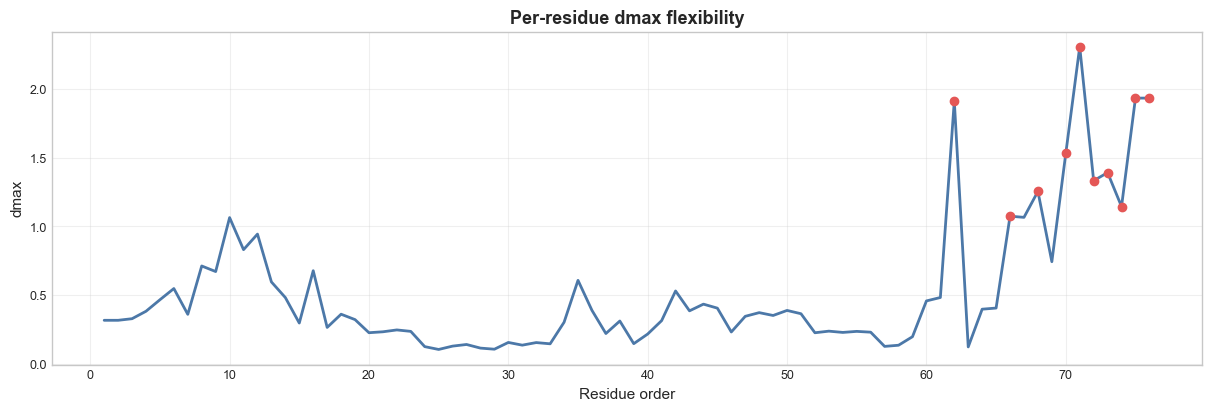

In [5]:
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
ax.plot(residue_summary_df["order"], residue_summary_df["dmax"], color="#4c78a8", linewidth=2)
ax.scatter(top_dmax["order"], top_dmax["dmax"], color="#e45756", s=36, zorder=3)
ax.set_xlabel("Residue order")
ax.set_ylabel("dmax")
ax.set_title("Per-residue dmax flexibility")
ax.grid(alpha=0.3)
plt.show()

## Tune the outlier threshold without rerunning Melodia

Once `result.raw_df` exists, you can recompute the summary with a different `dmax_outlier_fraction`. This is useful for sensitivity checks because it avoids recomputing the descriptors from the PDB file.

In [6]:
geometry = GeometryService()
summary_1pct = geometry.summarize(result.raw_df, dmax_outlier_fraction=0.01)
summary_5pct = geometry.summarize(result.raw_df, dmax_outlier_fraction=0.05)

dmax_comparison = summary_1pct[["chain", "order", "residue_label", "dmax"]].merge(
    summary_5pct[["chain", "order", "residue_label", "dmax"]],
    on=["chain", "order", "residue_label"],
    suffixes=("_1pct", "_5pct"),
)
dmax_comparison["delta"] = dmax_comparison["dmax_5pct"] - dmax_comparison["dmax_1pct"]

dmax_comparison.reindex(dmax_comparison["delta"].abs().sort_values(ascending=False).index).head(10)

,chain,order,residue_label,dmax_1pct,dmax_5pct,delta
70,A,71,LEU71,2.307649,1.050259,-1.257389
69,A,70,VAL70,1.530943,0.831807,-0.699135
61,A,62,GLN62,1.912897,1.266146,-0.646750
73,A,74,ARG74,1.144215,0.560714,-0.583501
65,A,66,THR66,1.074062,0.532896,-0.541166
11,A,12,THR12,0.943668,0.423898,-0.519770
10,A,11,LYS11,0.830345,0.341754,-0.488591
9,A,10,GLY10,1.063890,0.589513,-0.474377
8,A,9,THR9,0.670934,0.262648,-0.408286
67,A,68,HIS68,1.254519,0.850386,-0.404133


## Inspect one residue in curvature/torsion space

The next cell plots all model observations for the residue with the largest `dmax`, with dashed lines showing the trimmed extrema used in the calculation.

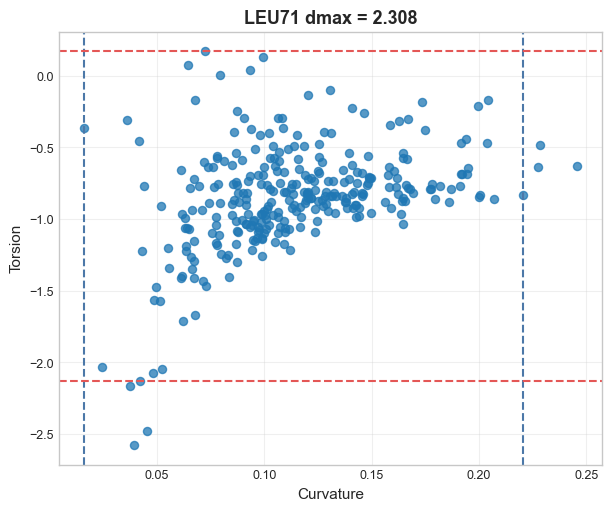

In [7]:
selected = top_dmax.iloc[0]
residue_points = result.raw_df[
    (result.raw_df["chain"] == selected["chain"])
    & (result.raw_df["order"] == selected["order"])
].copy()

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.scatter(residue_points["curvature"], residue_points["torsion"], s=34, alpha=0.75)
ax.axvline(selected["curvature_dmax_min"], color="#4c78a8", linestyle="--", linewidth=1.5)
ax.axvline(selected["curvature_dmax_max"], color="#4c78a8", linestyle="--", linewidth=1.5)
ax.axhline(selected["torsion_dmax_min"], color="#e45756", linestyle="--", linewidth=1.5)
ax.axhline(selected["torsion_dmax_max"], color="#e45756", linestyle="--", linewidth=1.5)
ax.set_xlabel("Curvature")
ax.set_ylabel("Torsion")
ax.set_title(f"{selected['residue_label']} dmax = {selected['dmax']:.3f}")
ax.grid(alpha=0.3)
plt.show()

## Save a dmax table

When you only need the flexibility metric and supporting extrema, select the `dmax` columns and write a compact table.

In [8]:
dmax_table = residue_summary_df[dmax_columns].copy()
dmax_output_path = OUTPUT_DIR / "dmax_residue_summary.csv"
dmax_table.to_csv(dmax_output_path, index=False)
print(f"Saved {dmax_output_path}")
dmax_table.head()

Saved /var/folders/b7/m1b34cvd23lg7p7rspz3yqnh0000gp/T/flexgeo2-dmax-arourh4u/dmax_residue_summary.csv


,chain,order,residue_label,curvature_min,curvature_max,curvature_dmax_min,curvature_dmax_max,torsion_min,torsion_max,torsion_dmax_min,torsion_dmax_max,dmax
0,A,1,MET1,0.325864,0.699961,0.325864,0.634132,-0.051142,0.036073,-0.051142,0.018040,0.315936
1,A,2,GLN2,0.325864,0.699961,0.325864,0.634132,-0.051142,0.036073,-0.051142,0.018040,0.315936
2,A,3,ILE3,0.419426,0.815847,0.419426,0.740639,-0.121378,-0.036480,-0.121378,-0.057238,0.327555
3,A,4,PHE4,0.414580,0.939250,0.462438,0.840768,-0.151191,-0.077521,-0.151191,-0.100278,0.381740
4,A,5,VAL5,0.603803,1.123519,0.603803,1.066452,-0.148288,-0.065921,-0.127934,-0.076663,0.465481
